In [1]:
import sys
sys.path.append("../../src")
sys.path.append("../../data")

import os
import numpy as np
from numba import njit
from scipy.stats import ortho_group
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt

from python_utils.visualization_utils import display_matrix, plot_bss_comparison, subplot_1D_signals
from bss.bss_utils import generate_uncorrelated_uniform_sources, addWGN, ProjectRowstoL1NormBall
from bss.PredictiveDecorrBSS_OlshaussenExp import PredictiveDecorrOlshaussen

# Read Image Patches

In [2]:
image_paths = '../../data/Olshaussen'
X_patches = scipy.io.loadmat(os.path.join(image_paths,'imagepatcheselfwhitened.mat'))['imagepatches']

In [3]:
X_patches.shape

(144, 312500)

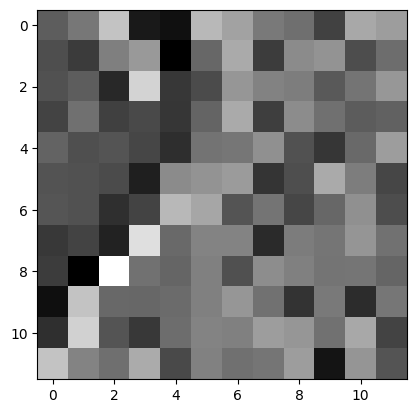

In [4]:
plt.imshow(X_patches[:, 0].reshape(12, 12), cmap = "gray")

# Hyperparameters

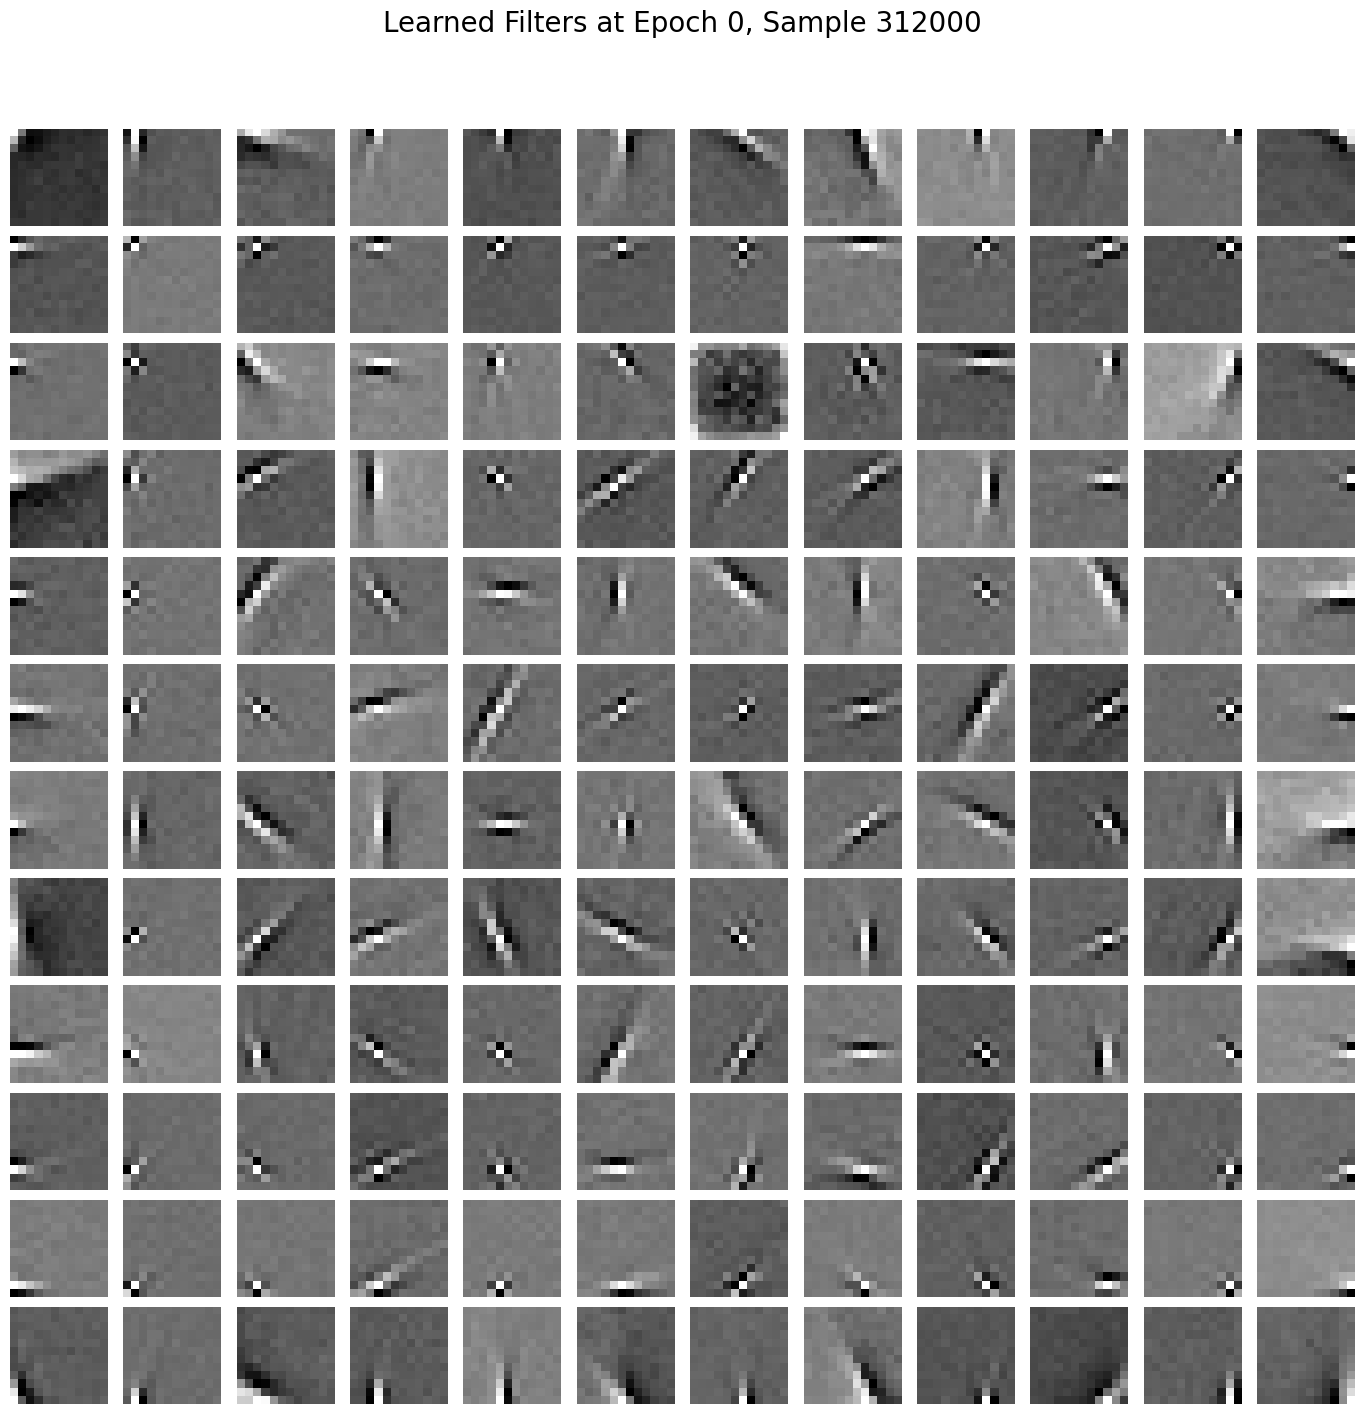

100%|███████████████████████████████████████████████████████████████████████████████████████████| 312500/312500 [32:07<00:00, 162.13it/s]


<Figure size 3600x2400 with 0 Axes>

In [5]:
seed = 100
np.random.seed(seed)
NumberofSources = 144
NumberofMixtures = 144
hyperparam_dict = {
                "n_sources" :  NumberofSources,
                "presumed_domain" : "sparse",
                ### Optimization parameters
                "lambda_lateral" : 1 - 1e-3/7,
                "gamma_predictive" : 3,
                ### Learning rates 
                "lr_W" : 1e-3 / 10,
                "neural_lr_start" : 0.05,
                "neural_lr_stop" : 1e-6,
                "stlambda_lr" : 5e-2,
                "neural_dynamics_iterations" : 500,
                "neural_OUTPUT_COMP_TOL" : 1e-6,
                ### Learning rate rules and decay parameters
                "lr_W_rule" : "constant",
                "lr_W_decay_divider" : 5000,
                "neural_lr_rule" : "divide_by_slow_loop_index",
                "neural_lr_decay_divider" : 100,
                ### Initial values for weights if provided, if not they will be initialized in the fit function 
                "W" : None,
                "C_y" : None,
                "mu_y" : None, 
                ### Ground truth source vectors. This part is only for debugging.
                "Sgt" : None,
                "debug_iteration_point" : 1000,
                "plot_debug_during_training" : True,
}
model = PredictiveDecorrOlshaussen(**hyperparam_dict)
model.C_y = np.eye(NumberofSources) / 1. + np.random.randn(NumberofSources, NumberofSources) / 250
model.W = np.eye(NumberofSources, NumberofMixtures) * 1.0 + np.random.randn(NumberofSources, NumberofMixtures) / 250
model.fit(X_patches)

In [6]:
display_matrix(model.C_y[:5, :5])

<IPython.core.display.Math object>

In [7]:
display_matrix(model.mu_y.reshape(1, -1)[:, :5])

<IPython.core.display.Math object>

In [8]:
display_matrix(model.W[:5, :5])

<IPython.core.display.Math object>

# Plot the final receptive filters

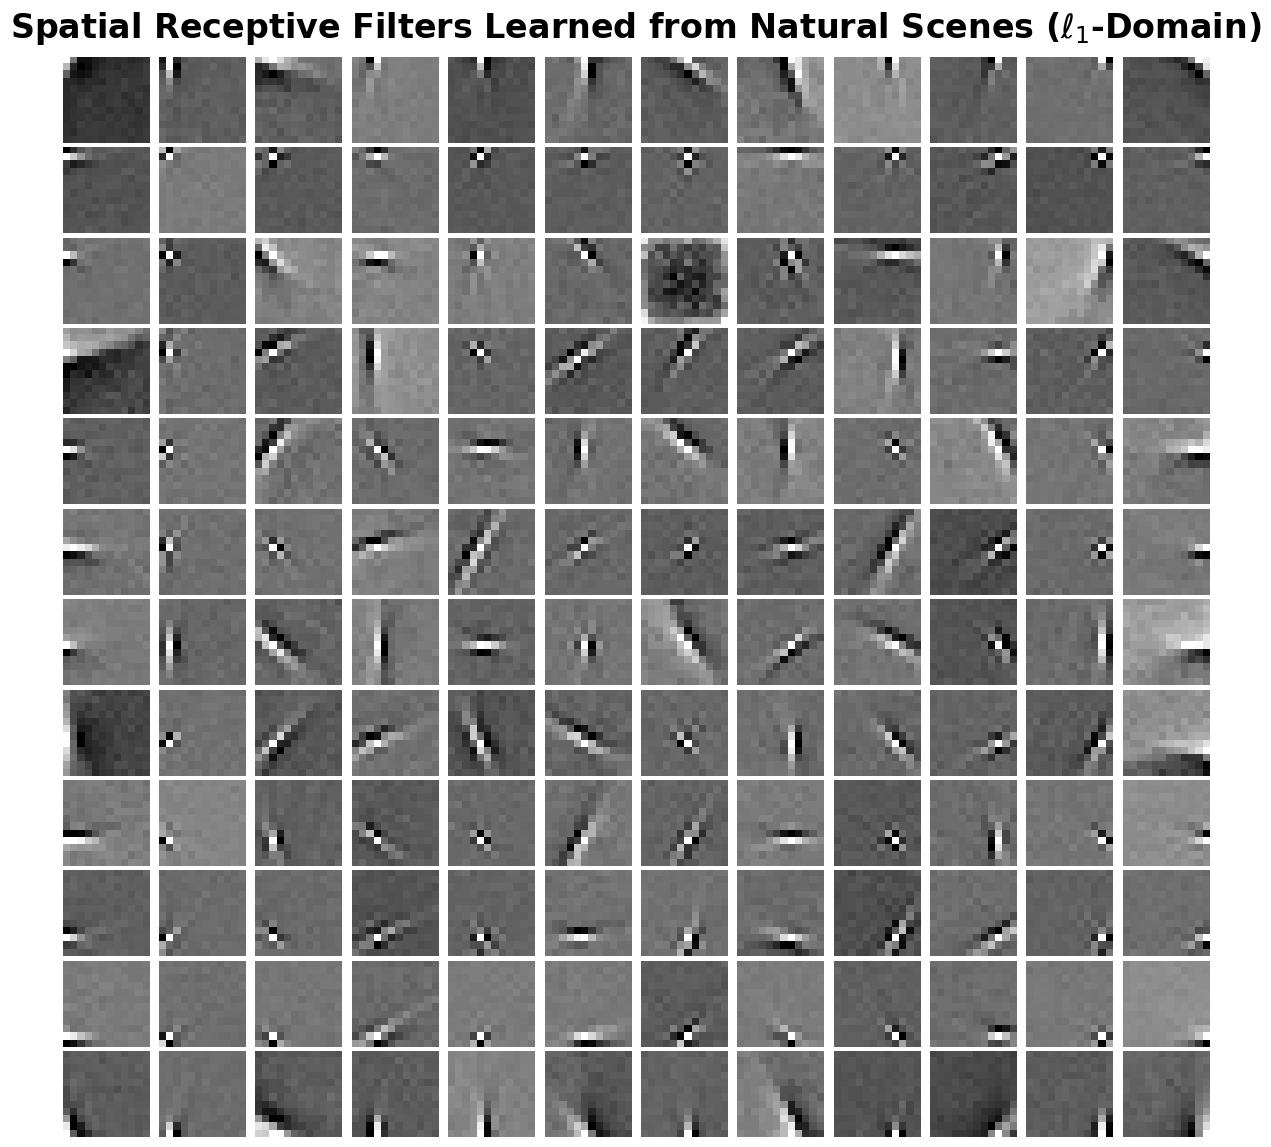

In [13]:
patch_size = (12, 12)
# Recommended publication title
title = f"Spatial Receptive Filters Learned from Natural Scenes ($\ell_1$-Domain)" 
W = model.W
n_filters = W.shape[0]

# 1. Calculate grid dimensions
n_cols = int(np.ceil(np.sqrt(n_filters)))
n_rows = int(np.ceil(n_filters / n_cols))

# 2. Setup figure
# Reduced figsize slightly to keep patches dense
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 12)) 

# Adjust 'y' to move title down (0.93-0.95 is usually the sweet spot)
fig.suptitle(title, fontsize=24, fontweight='bold', y=0.96)

axes_flat = axes.flatten()

for i in range(n_filters):
    rf = W[i, :].reshape(patch_size)
    ax = axes_flat[i]
    # 'interpolation=None' or 'nearest' is best for seeing actual pixel weights
    ax.imshow(rf, cmap='gray', interpolation='nearest')
    ax.axis('off')
    
# 3. Hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# 4. Tighten the layout
# hspace and wspace control the gap between the small patches
# top=0.92 ensures the subplots expand closer to the suptitle
plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.02, right=0.98, bottom=0.02, top=0.92)

plt.show()